Code for conformal prediction for NN for informationally incomplete measurements.

In [ ]:
# import libs and files
import numpy as np 
import matplotlib.pyplot as plt
from time import time
import sys
from uq_utils import *
from utils import qst1
from run_conformal import *
import os


using device: mps


In [2]:
# def born_probs(rho, nQubits):
#     """Placeholder for your specific qst1 measurement logic."""
#     fi = qst1(rho, nQubits) 
#     return np.real_if_close(0.5 * (fi[0] + fi[1:]))

# def counts(prob, N):
#     born_prob = qst1(densityMat, nQubits)
#         born_prob_random = 0.5*(born_prob[0] + born_prob[random_idx])
#         counts = simulate_counts(born_prob_random, N)
#         f = np.real(uq_utils.fidelity(densityMat, sigma)) 
#     """Generates raw measurement outcomes (integers)."""
#     yPlus = np.random.binomial(N, np.clip(np.real(prob), 0, 1))
#     yMinus = N - yPlus
#     return np.hstack([yPlus/N, yMinus/N])

def counts(x, nQubits, nShots, random_idx):
    m = 4**nQubits
    fi = qst1(x, nQubits)

    # Return measurement probabilities
    if nShots is None:
        probs = np.vstack((0.5*(fi[0]+fi[1:]), 0.5*(fi[0]-fi[1:])))
        return sigma, x, probs

    fi_prob_random = 0.5*(fi[0] + fi[random_idx])
    # print(fi_prob.shape)
    # fi_prob_random = 0.5*(fi_prob[0] + fi_prob[random_idx])

    weights = [nShots]*random_idx.shape[0]

    yPlus = np.random.binomial(weights, np.real(fi_prob_random))
    yMinus = nShots - yPlus

    # probs = np.vstack((yPlus/nShots, yMinus/nShots))
    probs = np.vstack((yPlus/weights, yMinus/weights))


    return probs.ravel()

# def generate_data(n_data, random_idx, N, sigma):
#     X = []
#     y = []
#     for i in range(n_data):
#         # alpha_beta = 3.0   # Beta distribution alpha > 1 downweights near 0
#         # beta_beta  = 1.0   # Beta distribution beta < 1 upweights near 1
#         # # delta = np.random.beta(alpha_beta, beta_beta, size=1).item()
#         # delta = np.random.uniform(0.0, 0.1)
#         # rho = (1-delta)*sigma + delta*randomState(nQubits, rank = 1)
#         # rho /= np.trace(rho)
#         # born_prob = qst1(rho, nQubits)
#         # born_prob_random = 0.5*(born_prob[0] + born_prob[random_idx])
#         # counts = simulate_counts(born_prob_random, N)
#         # f = np.real(fidelity(rho, sigma)) 
        

#         max_try = 10000
#         alpha_beta = 3.0   # Beta distribution alpha > 1 downweights near 0
#         beta_beta  = 1.0   # Beta distribution beta < 1 upweights near 1
#         f_tar = np.random.beta(alpha_beta, beta_beta, size=1).item()

#         for i in range(max_try):
#             if sigma.ndim == 1:  # Pure state vector
#                 tempState = uniform_sampling_on_simplex(2**nQubits, n_pts=1).ravel()
#                 tempState /= np.linalg.norm(tempState)

#                 c = np.vdot(tempState, sigma)
#                 c2 = np.sqrt(f_tar)

#                 # Quadratic coefficients
#                 A = (1 - c) * (1 - c - 2*c2**2)
#                 B = 2 * (1 - c) * (c + c2**2)
#                 C = c**2 - c2**2

#                 roots = np.roots([A, B, C])
#                 valid_alpha = roots[(roots >= 0) & (roots <= 1)]

#                 if valid_alpha.any():
#                     alpha = valid_alpha[0]
#                     rho_vec = alpha * sigma + (1 - alpha) * tempState
#                     rho_vec /= np.linalg.norm(rho_vec)
#                     densityMat = rho_vec[:, None] @ np.conj(rho_vec)[None, :]
                    
#                     break

#             elif sigma.ndim == 2:  # Mixed state density matrix
#                 tempState = np.random.randn(2**nQubits, 1) + 1j*np.random.randn(2**nQubits, 1)
#                 tempState = tempState @ tempState.conj().T
#                 tempState /= np.trace(tempState)

#                 c = np.vdot(tempState.flatten(), sigma.flatten())
#                 alpha = (f_tar - c)/(1 - c)

#                 if 0 < alpha < 1:
#                     rho = alpha * sigma + (1 - alpha) * tempState
#                     densityMat = rho
          
#                     break

#             # # fallback if max_try reached
#             # if i == max_try - 1:
#             #     warnings.warn("Max try exceeded; using random convex combination fallback")
#             #     eps = np.random.uniform(0.1, 0.5)
#             #     if sigma.ndim == 1:
#             #         rho_sigma = sigma[:, None] @ np.conj(sigma)[None, :]
#             #         rho_temp = tempState[:, None] @ np.conj(tempState)[None, :]
#             #         densityMat = (1 - eps) * rho_sigma + eps * rho_temp
#             #     else:
#             #         densityMat = (1 - eps) * sigma + eps * tempState
#             #     densityMat /= np.trace(densityMat)

#         # --- Pauli measurement probabilities ---

#         born_prob = qst1(densityMat, nQubits)
#         born_prob_random = 0.5*(born_prob[0] + born_prob[random_idx])
#         counts = simulate_counts(born_prob_random, N)
#         f = np.real(uq_utils.fidelity(densityMat, sigma)) 
#         # print(np.trace(densityMat), f, f_tar)

#         X.append(counts)
#         y.append(f)


        
#     return np.array(X), np.array(y)

In [ ]:
# select random set of measurements and build dataset
# define the percentage of measurements to retain

nQubits = 2
m = 4**nQubits
N = 100
n_splits = 2
n_data = 10000
alpha = 0.1
save_path = "./results"
os.makedirs(save_path, exist_ok=True)
save = True

records = []
sigma = np.random.randn(2**nQubits, 1) + 1j*np.random.randn(2**nQubits, 1)
sigma_vec = sigma/np.linalg.norm(sigma)
sigma = sigma @ sigma.T.conj()
sigma /= np.trace(sigma)
states = [HS_state(N= 2**nQubits) for _ in range(10000)]

for ratio in np.arange(0.5, 1.05, 0.1):
    print(f'{ratio:.1%} measurements are retained')


    for i in range(n_splits):
        rng = np.random.default_rng(seed=i)
        print(f"  --> Split {i+1}/{n_splits}...")
        random_idx = rng.choice(np.arange(1, m), size = int(ratio*(m-1)), replace= False)
        
        X = [counts(rho, nQubits, N, random_idx) for rho in states]
        Y = [np.real(fidelity(rho, sigma)) for rho in states]
        X = np.asarray(X).astype(np.float32)
        Y = np.asarray(Y).astype(np.float32)

        # 2. Split dataset
        x_train, x_test, y_train, y_test = train_test_split(
            X, Y, test_size=0.2, random_state=int(rng.integers(0, 1e6)))

        n_train = x_train.shape[0]
        n_test = x_test.shape[0]

        idx = rng.permutation(n_train)
        n_half = int(np.floor(n_train/2))
        idx_train, idx_cal = idx[:n_half], idx[n_half:2*n_half]
        
        
        for method in ['Neural Net', 'Neural Net Local', 'Quantile Neural Net (Non-Conformal)', 'Asymmetric CQR Neural Net']:
            print(f"  --> Method {method}")
            # -----------------------------------------------------
            # METHOD A: CONFORMAL PREDICTION (Neural Net)
            # -----------------------------------------------------
            cp_cov, cp_len, y_lower, y_upper, cp_time, _ = run_experiment(
                method, nQubits, x_train, y_train, x_test, y_test, idx_train, idx_cal, alpha
            )
            
            records.append({
                "nQubits": nQubits, "nShots": N, "iter": i,
                "method": method,
                "coverage": cp_cov,
                "avg_length": cp_len,
                'ratio': ratio
            })
records = pd.DataFrame(records)
if save:
    records.to_csv(os.path.join(save_path, "incomplete_meas.csv"), index=False)

50.0% measurements are retained
  --> Split 1/20...
  --> Method Neural Net


KeyboardInterrupt: 

In [2]:
records.to_csv("/Users/aditi/Documents/Fall_25/Quantum/UQ/main/results/conformal_NN/incomplete_meas_n_2_new.csv", index=False)

NameError: name 'records' is not defined

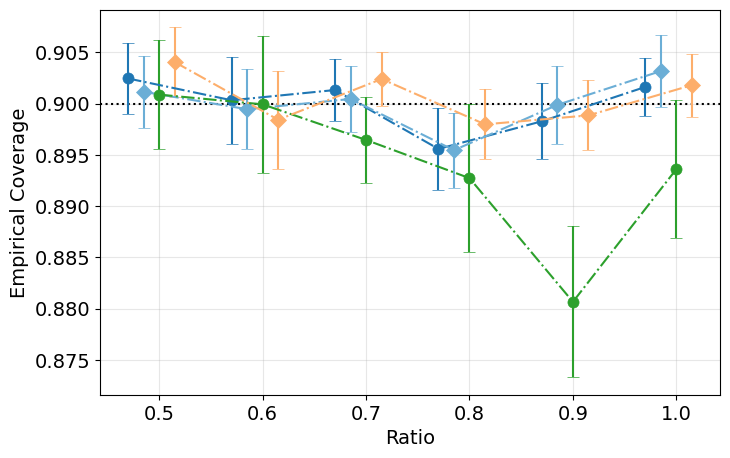

In [ ]:
records['coverage'] = records['coverage']/100

summary = records.groupby(["ratio", "method"]).agg(
    mean_cov=("coverage", "mean"),
    mean_len=("avg_length", "mean"),
    std_cov=("coverage", "std"),
    std_len=("avg_length", "std"),
    n_runs=("coverage", "count")
).reset_index()
summary["ci_cov"] = 1.96 * (summary["std_cov"] / np.sqrt(summary["n_runs"]))
summary["ci_len"] = 1.96 * (summary["std_len"] / np.sqrt(summary["n_runs"]))

plt.rcParams.update({'font.size': 14})
plt.figure(figsize=(8, 5))
ax = plt.gca()

ratios = sorted(records['ratio'].unique())
x_base = np.arange(len(ratios))
width = 0.15

method_colors = {
    'Neural Net': '#1f77b4',                 # blue
    'Neural Net Local': '#6baed6',           # light blue

    'Quantile Neural Net (Non-Conformal)': '#2ca02c',        # green

    'Symmetric CQR Neural Net': '#ff7f0e',   # orange
    'Asymmetric CQR Neural Net': '#fdae6b' # light orange
}
method_markers = {
    'Neural Net': "o",                 # blue
    'Neural Net Local': "D",           # light blue

    'Quantile Neural Net (Non-Conformal)': "o",        # green

    'Symmetric CQR Neural Net': "o",   # orange
    'Asymmetric CQR Neural Net': "D" # light orange
}
# --- Raw points (lighter, like your previous subtle noise) ---
# sns.stripplot(
#     data=records,
#     x="ratio",
#     y="coverage",
#     hue="method",
#     palette=method_colors,
#     dodge=True,
#     jitter=0.15,
#     alpha=0.25,
#     size=4,
#     ax=ax,
#     zorder=1
# )

# --- Mean + CI (your summary, not seaborn's) ---
for i, method in enumerate(records['method'].unique()):
    method_stats = summary[summary['method'] == method]
    offset = (i - (len(method_colors)-1)/2) * width

    ax.errorbar(
        x=x_base + offset,
        y=method_stats['mean_cov'],
        yerr=method_stats['ci_cov'],
        fmt=method_markers[method],
        linestyle='-.',
        color=method_colors[method],
        capsize=4,
        markersize=8,
        # markeredgecolor='black',
        markeredgewidth=0.5,
        elinewidth=1.5,
        zorder=10,
        label=method
    )

ax.axhline(0.9, linestyle="dotted", color='black', label="Target Coverage")

ax.set_xticks(x_base)
ax.set_xticklabels([f"{r:.1f}" for r in ratios], fontsize=14)
# ax.tick_params(
#     axis='both',          # Apply to both x and y axes
#     which='major',        # Only major ticks
#     direction='out',      # Ticks point out from the plot
#     length=6,             # Length of the dash
#     width=1.5,           # Thickness of the dash
#     color='black',        # Color of the dash
#     labelsize=14          # Ensure labels are legible
# )

ax.set_xlabel("Ratio", fontsize=14)
ax.set_ylabel("Empirical Coverage", fontsize=14)
ax.grid(True, alpha=0.3)


# Keep box (no despine)
for spine in ax.spines.values():
    spine.set_visible(True)

# Clean legend (avoid duplicates from stripplot)
handles, labels = ax.get_legend_handles_labels()
# ax.legend(handles[:len(method_colors)+1], labels[:len(method_colors)+1])

plt.savefig(os.path.join(save_path, "incomplete_meas_cov.pdf"),
            bbox_inches='tight', dpi=300)

plt.show()

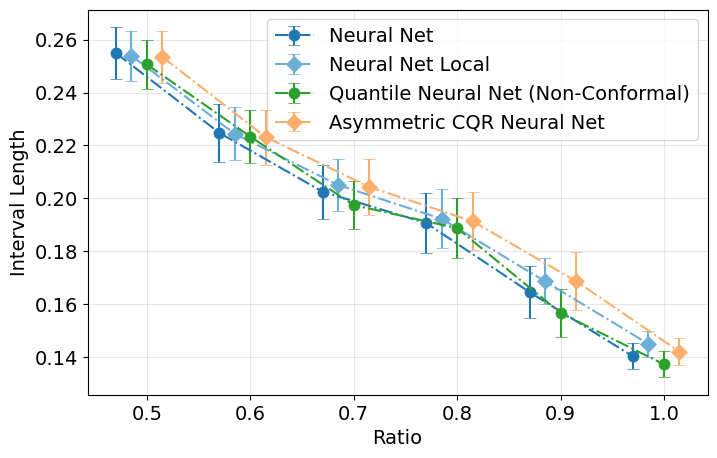

In [ ]:
plt.rcParams.update({'font.size': 14})
plt.figure(figsize=(8, 5))
ax = plt.gca()

ratios = sorted(records['ratio'].unique())
x_base = np.arange(len(ratios))
width = 0.15
# --- Mean + CI (your summary, not seaborn's) ---
for i, method in enumerate(records['method'].unique()):
    method_stats = summary[summary['method'] == method]
    offset = (i - (len(method_colors)-1)/2) * width

    ax.errorbar(
        x=x_base + offset,
        y=method_stats['mean_len'],
        yerr=method_stats['ci_len'],
        fmt=method_markers[method],
        linestyle='-.',
        color=method_colors[method],
        capsize=4,
        markersize=8,
        # markeredgecolor='black',
        markeredgewidth=0.5,
        elinewidth=1.5,
        zorder=10,
        label=method
    )


ax.set_xticks(x_base)
ax.set_xticklabels([f"{r:.1f}" for r in ratios], fontsize=14)

ax.set_xlabel("Ratio", fontsize=14)
ax.set_ylabel("Interval Length", fontsize=14)

ax.grid(True, alpha=0.3)


# Keep box (no despine)
for spine in ax.spines.values():
    spine.set_visible(True)

# Clean legend (avoid duplicates from stripplot)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:len(method_colors)+1], labels[:len(method_colors)+1])

plt.savefig(os.path.join(save_path, "incomplete_meas_len.pdf"),
            bbox_inches='tight', dpi=300)

plt.show()